# Monte Carlo Options Pricing Model
## European Call Option Pricing using Geometric Brownian Motion
### Cynthia Wanjiru | WashU MSFQ 2026

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

## Step 1: Option parameters
We use real AAPL market data to derive the current stock price and historical 
volatility. Strike price is set 5% above current price (out of the money), 
with a 1-year expiration.

In [3]:
# Download real AAPL data
ticker = 'AAPL'
data = yf.download(ticker, start='2023-01-01', end='2024-12-31')['Close']

# Calculate inputs from real data
S = float(data.iloc[-1].iloc[0])
returns = data.pct_change().dropna()
sigma = float(returns.std().iloc[0] * np.sqrt(252))

# Option parameters
K = round(S * 1.05, 2)
T = 1.0
r = 0.05
N = 10000

print(f"Current AAPL Price (S): ${S:.2f}")
print(f"Strike Price (K):       ${K:.2f}")
print(f"Annualized Volatility:  {sigma*100:.2f}%")
print(f"Time to Expiration:     {T} year")
print(f"Risk-Free Rate:         {r*100:.1f}%")
print(f"Simulations:            {N:,}")

[*********************100%***********************]  1 of 1 completed

Current AAPL Price (S): $250.83
Strike Price (K):       $263.37
Annualized Volatility:  21.37%
Time to Expiration:     1.0 year
Risk-Free Rate:         5.0%
Simulations:            10,000


## Step 2: Simulate Stock Price Paths using GBM
Geometric Brownian Motion models stock prices as a random walk with drift. 
We simulate 10,000 possible price paths to expiration.

In [7]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate random returns using GBM
Z = np.random.standard_normal(N)
ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

print(f"Simulated {N:,} possible AAPL prices at expiration")
print(f"Mean simulated price:    ${ST.mean():.2f}")
print(f"Min simulated price:     ${ST.min():.2f}")
print(f"Max simulated price:     ${ST.max():.2f}")

Simulated 10,000 possible AAPL prices at expiration
Mean simulated price:    $263.61
Min simulated price:     $111.48
Max simulated price:     $596.37


## Step 3: Calculate Option Payoff
A European Call option pays max(S_T - K, 0) at expiration.
We calculate the payoff for each simulated price path.

In [8]:
# Calculate call option payoff for each simulation
payoffs = np.maximum(ST - K, 0)

# Discount back to present value
MC_price = np.exp(-r * T) * np.mean(payoffs)

print(f"Option Payoffs — paths finishing in the money: {np.sum(payoffs > 0):,} / {N:,}")
print(f"Average Payoff at Expiration: ${np.mean(payoffs):.2f}")
print(f"Monte Carlo Option Price:     ${MC_price:.2f}")

Option Payoffs — paths finishing in the money: 4,587 / 10,000
Average Payoff at Expiration: $22.59
Monte Carlo Option Price:     $21.49


## Step 4: Black-Scholes Analytical Price
The Black-Scholes formula gives us the exact theoretical price. 
We use this to validate our Monte Carlo simulation.m walk with drift. 
We simulate 10,000 possible price paths to expiration.

In [9]:
# Black-Scholes formula
d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

BS_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"Black-Scholes d1:           {d1:.4f}")
print(f"Black-Scholes d2:           {d2:.4f}")
print(f"Black-Scholes Option Price: ${BS_price:.2f}")
print(f"Monte Carlo Option Price:   ${MC_price:.2f}")
print(f"Difference:                 ${abs(MC_price - BS_price):.2f}")

Black-Scholes d1:           0.1125
Black-Scholes d2:           -0.1012
Black-Scholes Option Price: $21.48
Monte Carlo Option Price:   $21.49
Difference:                 $0.01


## Step 5: Visualization
Distribution of simulated stock prices at expiration with 
Monte Carlo and Black-Scholes option prices compared.

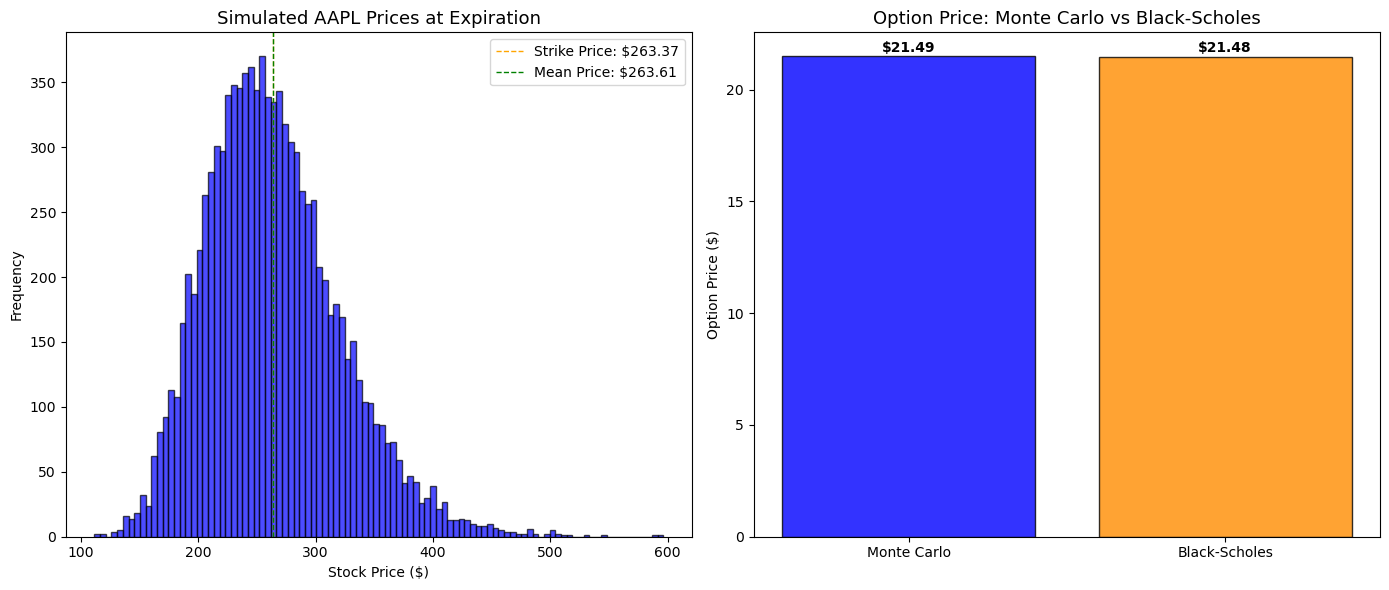

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Simulated price distribution
ax1.hist(ST, bins=100, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(K, color='orange', linestyle='--', linewidth=1, label=f'Strike Price: ${K}')
ax1.axvline(ST.mean(), color='green', linestyle='--', linewidth=1, 
            label=f'Mean Price: ${ST.mean():.2f}')
ax1.set_title('Simulated AAPL Prices at Expiration', fontsize=13)
ax1.set_xlabel('Stock Price ($)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Plot 2 — Monte Carlo vs Black-Scholes
methods = ['Monte Carlo', 'Black-Scholes']
prices = [MC_price, BS_price]
colors = ['blue', 'darkorange']
bars = ax2.bar(methods, prices, color=colors, edgecolor='black', alpha=0.8)
ax2.set_title('Option Price: Monte Carlo vs Black-Scholes', fontsize=13)
ax2.set_ylabel('Option Price ($)')
for bar, price in zip(bars, prices):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${price:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Summary

In [15]:
print("=" * 55)
print("MONTE CARLO OPTIONS PRICING — SUMMARY")
print("=" * 55)
print(f"Underlying Asset:           AAPL")
print(f"Current Stock Price (S):    ${S:.2f}")
print(f"Strike Price (K):           ${K:.2f}")
print(f"Time to Expiration:         {T} year")
print(f"Risk-Free Rate:             {r*100:.1f}%")
print(f"Annualized Volatility:      {sigma*100:.2f}%")
print(f"Simulations:                {N:,}")
print("-" * 55)
print(f"Monte Carlo Option Price:   ${MC_price:.2f}")
print(f"Black-Scholes Option Price: ${BS_price:.2f}")
print(f"Difference:                 ${abs(MC_price - BS_price):.2f}")
print("-" * 55)
print(f"Paths finishing in the money: {np.sum(payoffs > 0):,} / {N:,}")
print(f"Probability of profit:        {np.sum(payoffs > 0)/N*100:.1f}%")
print("=" * 55)

MONTE CARLO OPTIONS PRICING — SUMMARY
Underlying Asset:           AAPL
Current Stock Price (S):    $250.83
Strike Price (K):           $263.37
Time to Expiration:         1.0 year
Risk-Free Rate:             5.0%
Annualized Volatility:      21.37%
Simulations:                10,000
-------------------------------------------------------
Monte Carlo Option Price:   $21.49
Black-Scholes Option Price: $21.48
Difference:                 $0.01
-------------------------------------------------------
Paths finishing in the money: 4,587 / 10,000
Probability of profit:        45.9%
